In [1]:
from pathlib import Path
from collections import Counter

import yaml
import pandas as pd
import matplotlib.pyplot as plt

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


Connect the Notebook to the Dataset

In [2]:
from pathlib import Path

PROJECT_PATH = Path(r"E:\ML_Project")

DATASET_PATH = PROJECT_PATH / "datasets" / "bdd100k_original_yolo"

print(f"Project Path : {PROJECT_PATH}")
print(f"Dataset Path : {DATASET_PATH}")

Project Path : E:\ML_Project
Dataset Path : E:\ML_Project\datasets\bdd100k_original_yolo


Verify the Dataset Structure properly

In [3]:
train_images = DATASET_PATH / "train" / "images"
train_labels = DATASET_PATH / "train" / "labels"

valid_images = DATASET_PATH / "valid" / "images"
valid_labels = DATASET_PATH / "valid" / "labels"

test_images = DATASET_PATH / "test" / "images"
test_labels = DATASET_PATH / "test" / "labels"

data_yaml = DATASET_PATH / "bdd100k.yaml"

paths = {
    "Train Images": train_images,
    "Train Labels": train_labels,

    "Validation Images": valid_images,
    "Validation Labels": valid_labels,

    "Test Images": test_images,
    "Test Labels": test_labels,

    "bdd100k.yaml": data_yaml,
}

print("=" * 60)
print("Dataset Structure Verification")
print("=" * 60)

all_found = True

for name, path in paths.items():

    if path.exists():
        print(f"✓ {name:<20}: FOUND")
    else:
        print(f"✗ {name:<20}: NOT FOUND")
        all_found = False

print("=" * 60)

if all_found:
    print("✓ Dataset structure verified successfully.")
else:
    print("✗ Dataset structure verification failed.")

Dataset Structure Verification
✓ Train Images        : FOUND
✓ Train Labels        : FOUND
✓ Validation Images   : FOUND
✓ Validation Labels   : FOUND
✓ Test Images         : FOUND
✓ Test Labels         : FOUND
✓ bdd100k.yaml        : FOUND
✓ Dataset structure verified successfully.


Count all the Images

In [4]:
train_image_count = len(list(train_images.glob("*.jpg")))
valid_image_count = len(list(valid_images.glob("*.jpg")))
test_image_count  = len(list(test_images.glob("*.jpg")))

total_images = (
    train_image_count +
    valid_image_count +
    test_image_count
)

print("=" * 60)
print("Image Statistics")
print("=" * 60)

print(f"Training Images    : {train_image_count:,}")
print(f"Validation Images  : {valid_image_count:,}")
print(f"Testing Images     : {test_image_count:,}")

print("-" * 60)
print(f"Total Images       : {total_images:,}")

# Verify against expected dataset size
EXPECTED_IMAGES = 100000

print()

if total_images == EXPECTED_IMAGES:
    print("✓ Image count matches the expected dataset size.")
else:
    print(f"⚠ Expected {EXPECTED_IMAGES:,} images, but found {total_images:,}.")

Image Statistics
Training Images    : 70,000
Validation Images  : 10,000
Testing Images     : 20,000
------------------------------------------------------------
Total Images       : 100,000

✓ Image count matches the expected dataset size.


Count the Label Files

In [6]:
# Count image files
train_image_count = len(list(train_images.glob("*.jpg")))
valid_image_count = len(list(valid_images.glob("*.jpg")))
test_image_count  = len(list(test_images.glob("*.jpg")))

# Total images
total_images = (
    train_image_count +
    valid_image_count +
    test_image_count
)

print("=" * 60)
print("Image Statistics")
print("=" * 60)

print(f"Training Images    : {train_image_count:,}")
print(f"Validation Images  : {valid_image_count:,}")
print(f"Testing Images     : {test_image_count:,}")

print("-" * 60)
print(f"Total Images       : {total_images:,}")

Image Statistics
Training Images    : 70,000
Validation Images  : 10,000
Testing Images     : 20,000
------------------------------------------------------------
Total Images       : 100,000


Verify Image–Label Pairing

In [7]:
def check_image_label_pairs(image_dir, label_dir):

    image_names = {img.stem for img in image_dir.glob("*.jpg")}
    label_names = {lbl.stem for lbl in label_dir.glob("*.txt")}

    missing_labels = image_names - label_names
    extra_labels = label_names - image_names

    return missing_labels, extra_labels



# Training Set
train_missing, train_extra = check_image_label_pairs(
    train_images,
    train_labels
)

# Validation Set
valid_missing, valid_extra = check_image_label_pairs(
    valid_images,
    valid_labels
)

# Testing Set
test_missing, test_extra = check_image_label_pairs(
    test_images,
    test_labels
)

print("=" * 60)
print("Image–Label Pair Verification")
print("=" * 60)

print(f"Training Missing Labels   : {len(train_missing)}")
print(f"Training Extra Labels     : {len(train_extra)}")

print()

print(f"Validation Missing Labels : {len(valid_missing)}")
print(f"Validation Extra Labels   : {len(valid_extra)}")

print()

print(f"Testing Missing Labels    : {len(test_missing)}")
print(f"Testing Extra Labels      : {len(test_extra)}")

print("-" * 60)

total_missing = (
    len(train_missing)
    + len(valid_missing)
    + len(test_missing)
)

total_extra = (
    len(train_extra)
    + len(valid_extra)
    + len(test_extra)
)

print(f"Total Missing Labels      : {total_missing}")
print(f"Total Extra Labels        : {total_extra}")

print()

if total_missing == 0 and total_extra == 0:
    print("✓ Image–Label correspondence verified successfully.")
else:
    print("✗ Image–Label correspondence verification failed.")

    # Show a few examples for debugging
    print("\nExample Missing Labels:")
    print(list(train_missing)[:5] + list(valid_missing)[:5] + list(test_missing)[:5])

    print("\nExample Extra Labels:")
    print(list(train_extra)[:5] + list(valid_extra)[:5] + list(test_extra)[:5])

Image–Label Pair Verification
Training Missing Labels   : 0
Training Extra Labels     : 0

Validation Missing Labels : 0
Validation Extra Labels   : 0

Testing Missing Labels    : 0
Testing Extra Labels      : 0
------------------------------------------------------------
Total Missing Labels      : 0
Total Extra Labels        : 0

✓ Image–Label correspondence verified successfully.


Count Total Object Annotations

In [8]:
def count_annotations(label_folder):
    total_objects = 0

    for label_file in label_folder.glob("*.txt"):
        with open(label_file, "r") as f:
            total_objects += sum(1 for line in f if line.strip())

    return total_objects


# Count objects in each split
train_objects = count_annotations(train_labels)
valid_objects = count_annotations(valid_labels)
test_objects  = count_annotations(test_labels)

# Total objects
total_objects = (
    train_objects +
    valid_objects +
    test_objects
)

print("=" * 60)
print("Object Annotation Statistics")
print("=" * 60)

print(f"Training Objects    : {train_objects:,}")
print(f"Validation Objects  : {valid_objects:,}")
print(f"Testing Objects     : {test_objects:,}")

print("-" * 60)
print(f"Total Objects       : {total_objects:,}")

print()

average_objects = total_objects / total_images
print(f"Average Objects/Image : {average_objects:.2f}")

Object Annotation Statistics
Training Objects    : 1,288,010
Validation Objects  : 185,526
Testing Objects     : 367,621
------------------------------------------------------------
Total Objects       : 1,841,157

Average Objects/Image : 18.41


In [9]:
with open(data_yaml, "r") as f:
    data_config = yaml.safe_load(f)

print("✓ Dataset configuration loaded successfully.")

✓ Dataset configuration loaded successfully.


Class Distribution. Here, we will count how many object is actually belong to each class

In [11]:
from collections import Counter

class_counts = Counter()

for label_folder in [train_labels, valid_labels, test_labels]:
    for label_file in label_folder.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:

            for line in f:
                line = line.strip()
                if not line:
                    continue

                class_id = int(line.split()[0])
                class_counts[class_id] += 1


print("=" * 60)
print("Class Distribution")
print("=" * 60)

for class_id in sorted(class_counts):
    print(
        f"{class_id:2d} : "
        f"{class_names[class_id]:<20} "
        f"{class_counts[class_id]:,}"
    )

print("=" * 60)
print(f"Total Objects : {sum(class_counts.values()):,}")

Class Distribution
 0 : bike                 10,229
 1 : bus                  16,498
 2 : car                  1,021,517
 3 : motor                4,295
 4 : person               129,308
 5 : rider                6,463
 6 : traffic light        265,926
 7 : traffic sign         343,793
 8 : train                179
 9 : truck                42,949
Total Objects : 1,841,157


Class Distribution Visualization

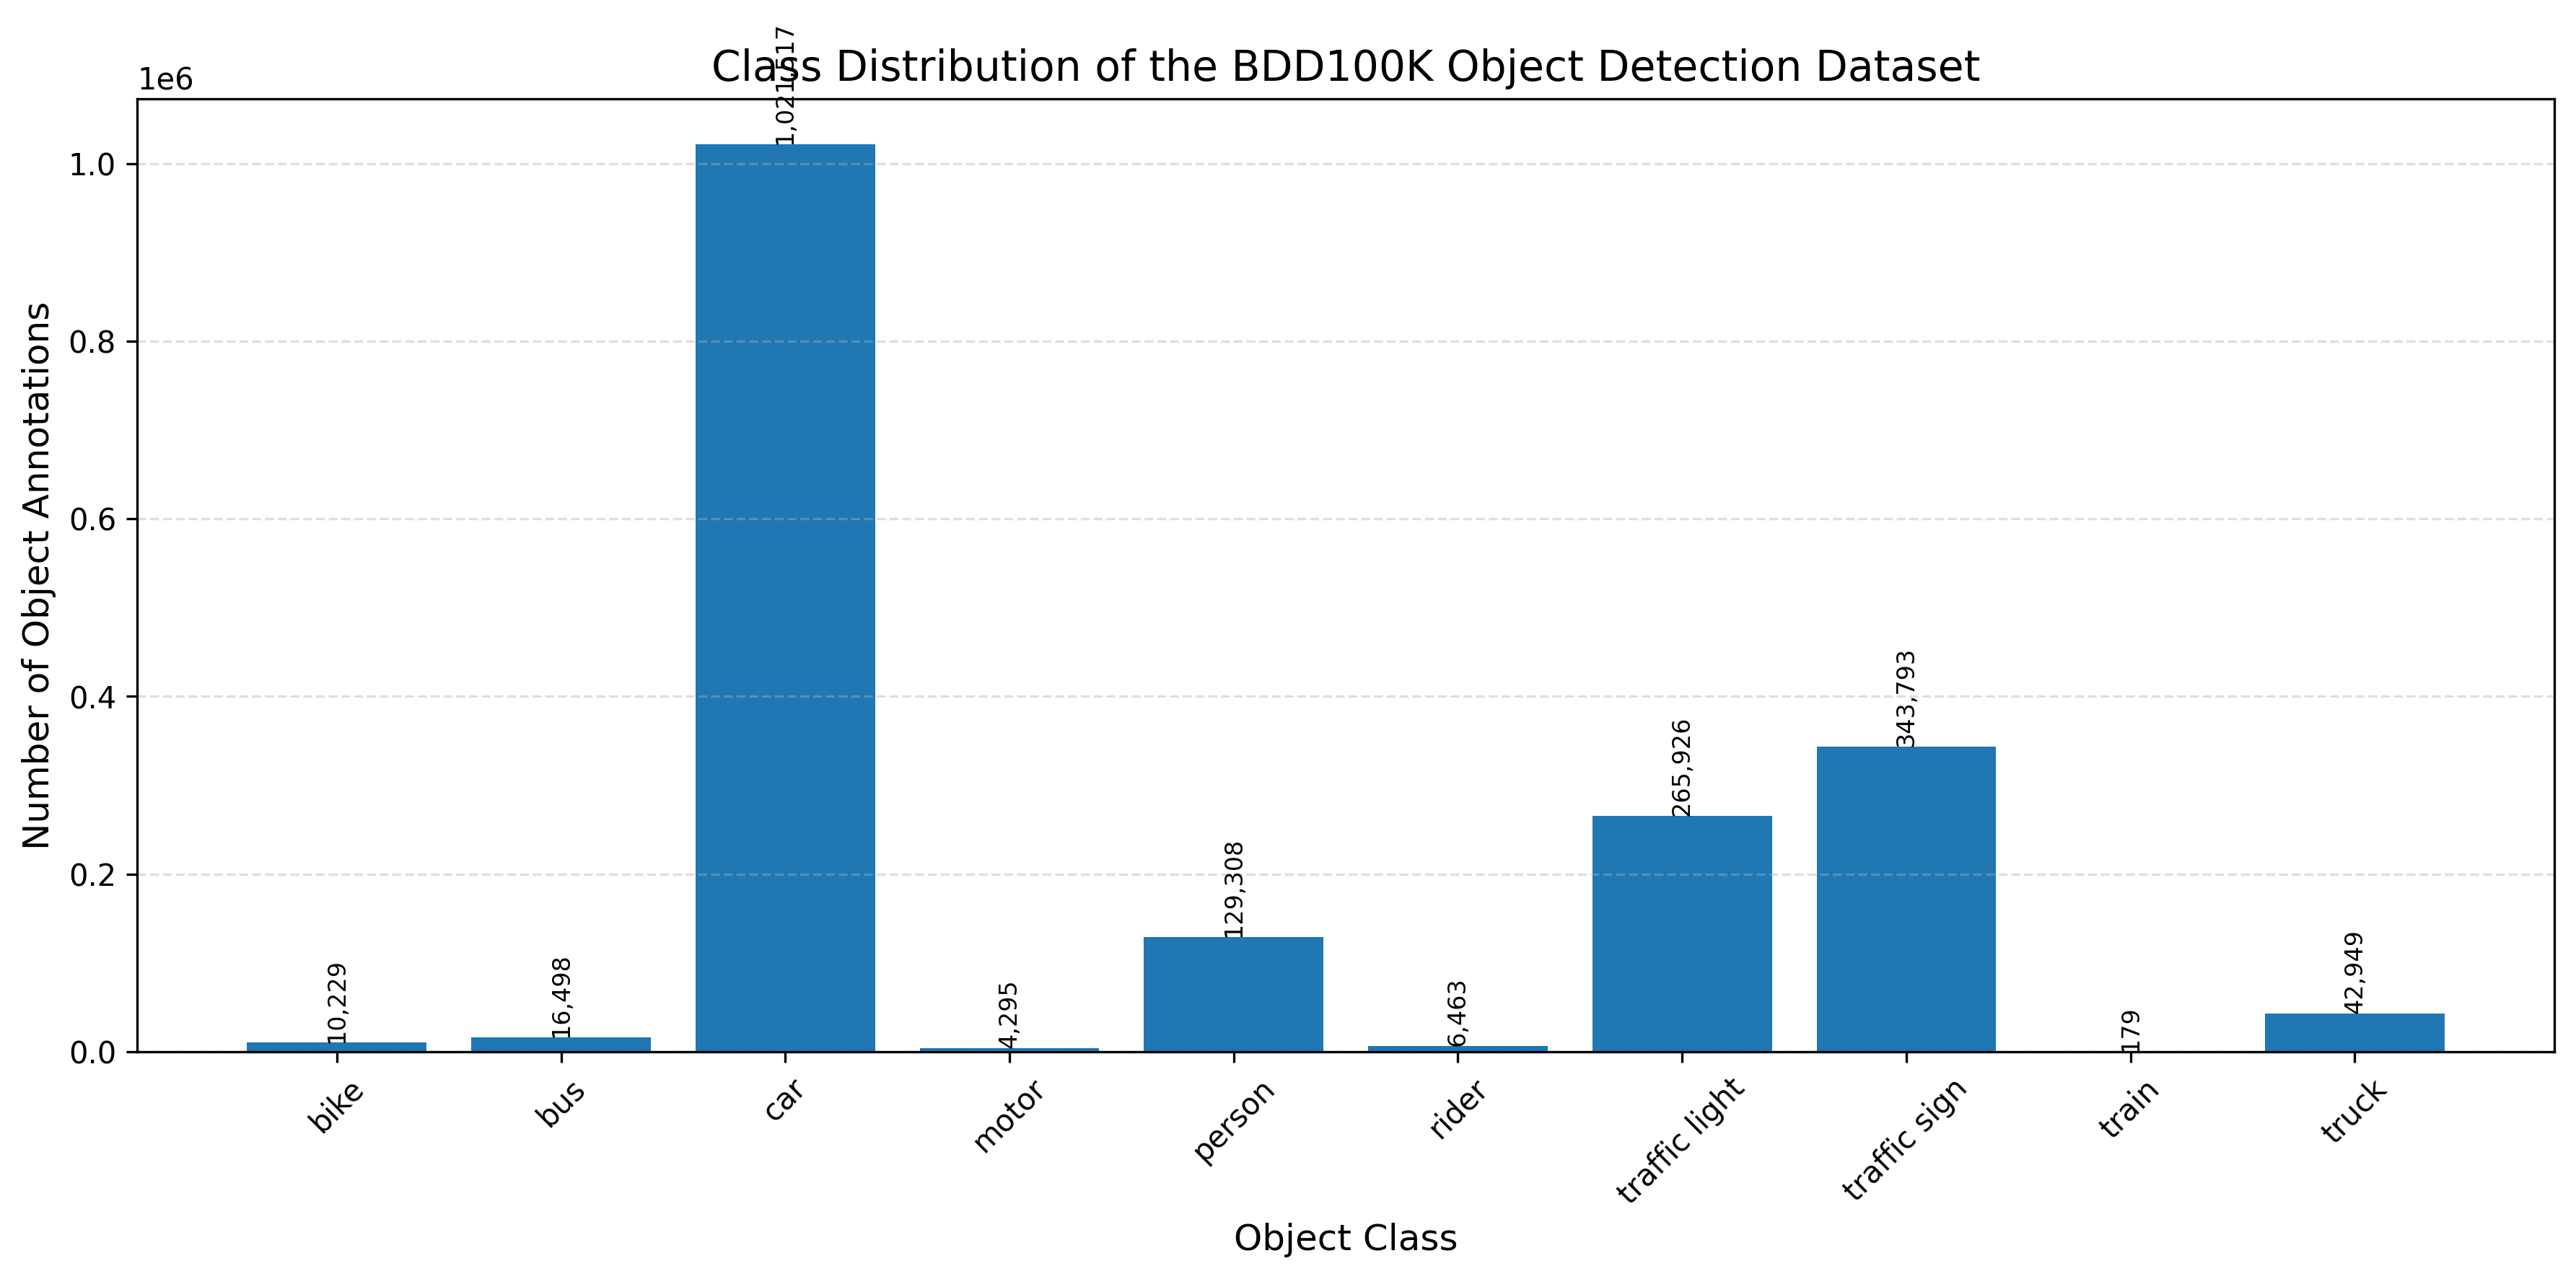


✓ Figure saved successfully.
Location : E:\ML_Project\figures\class_distribution.png


In [12]:


# Prepare class names accurately
names = data_config["names"]
if isinstance(names, dict):
    class_names = [names[i] for i in range(len(names))]
else:
    class_names = list(names)

counts = [class_counts[i] for i in range(len(class_names))]

# Create figure
plt.figure(figsize=(12, 6), dpi=300)

bars = plt.bar(class_names, counts)

# Add annotation values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

# Figure to formatting properly
plt.title(
    "Class Distribution of the BDD100K Object Detection Dataset",
    fontsize=14
)

plt.xlabel("Object Class", fontsize=12)
plt.ylabel("Number of Object Annotations", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()


# Save all of the Figure
figure_folder = PROJECT_PATH / "figures"
figure_folder.mkdir(exist_ok=True)

figure_path = figure_folder / "class_distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

print()
print("✓ Figure saved successfully.")
print(f"Location : {figure_path}")

Class Distribution Visualization. Here, we will visualize the quality of the figures in the publications

Empty Label File Verification

In [15]:
def count_empty_labels(label_folder):
    empty_files = []

    for label_file in label_folder.glob("*.txt"):
        if label_file.stat().st_size == 0:
            empty_files.append(label_file.name)

    return empty_files

train_empty = count_empty_labels(train_labels)
valid_empty = count_empty_labels(valid_labels)
test_empty = count_empty_labels(test_labels)

total_empty = (
    len(train_empty)
    + len(valid_empty)
    + len(test_empty)
)

print("=" * 60)
print("Empty Label File Verification")
print("=" * 60)

print(f"Training Empty Labels   : {len(train_empty)}")
print(f"Validation Empty Labels : {len(valid_empty)}")
print(f"Testing Empty Labels    : {len(test_empty)}")

print("-" * 60)
print(f"Total Empty Labels      : {total_empty}")

print()

if total_empty == 0:
    print("✓ No empty label files found.")
else:
    print("✗ Empty label files detected.")

Empty Label File Verification
Training Empty Labels   : 0
Validation Empty Labels : 0
Testing Empty Labels    : 0
------------------------------------------------------------
Total Empty Labels      : 0

✓ No empty label files found.


Invalid Class ID Verification

In [16]:
num_classes = len(data_config["names"])

invalid_class_ids = []

def verify_class_ids(label_folder):

    for label_file in label_folder.glob("*.txt"):

        with open(label_file, "r") as f:

            for line_no, line in enumerate(f, start=1):

                if line.strip():

                    class_id = int(line.split()[0])

                    if class_id < 0 or class_id >= num_classes:

                        invalid_class_ids.append(
                            (label_file.name, line_no, class_id)
                        )


verify_class_ids(train_labels)
verify_class_ids(valid_labels)
verify_class_ids(test_labels)

print("=" * 60)
print("Invalid Class ID Verification")
print("=" * 60)

print(f"Invalid Class IDs : {len(invalid_class_ids)}")

if invalid_class_ids:
    print("\nFirst 5 Invalid Entries")

    for item in invalid_class_ids[:5]:
        print(item)
else:
    print("✓ All class IDs are valid.")

Invalid Class ID Verification
Invalid Class IDs : 0
✓ All class IDs are valid.


Bounding Box Verification

In [17]:
invalid_boxes = []

def verify_bounding_boxes(label_folder):
    for label_file in label_folder.glob("*.txt"):
        with open(label_file, "r") as f:
            for line_no, line in enumerate(f, start=1):
                parts = line.strip().split()

                if len(parts) != 5:
                    invalid_boxes.append(
                        (label_file.name, line_no, "Wrong Format")
                    )
                    continue

                _, x, y, w, h = map(float, parts)

                if not (
                    0 <= x <= 1 and
                    0 <= y <= 1 and
                    0 < w <= 1 and
                    0 < h <= 1
                ):
                    invalid_boxes.append(
                        (label_file.name, line_no, "Invalid Coordinates")
                    )


verify_bounding_boxes(train_labels)
verify_bounding_boxes(valid_labels)
verify_bounding_boxes(test_labels)

print("=" * 60)
print("Bounding Box Verification")
print("=" * 60)
print(f"Invalid Bounding Boxes : {len(invalid_boxes)}")

if invalid_boxes:
    print("\nFirst 5 Invalid Entries")
    for item in invalid_boxes[:5]:
        print(item)
else:
    print("✓ All bounding boxes are valid.")

Bounding Box Verification
Invalid Bounding Boxes : 0
✓ All bounding boxes are valid.


Dataset Quality Summary

In [18]:
print("=" * 70)
print("DATASET QUALITY SUMMARY")
print("=" * 70)

print(f"Images                  : {total_images:,}")
print(f"Objects                 : {total_objects:,}")
print(f"Empty Label Files       : {total_empty}")
print(f"Missing Labels          : {total_missing}")
print(f"Extra Labels            : {total_extra}")
print(f"Invalid Class IDs       : {len(invalid_class_ids)}")
print(f"Invalid Bounding Boxes  : {len(invalid_boxes)}")

print()

if (
    total_empty == 0
    and total_missing == 0
    and total_extra == 0
    and len(invalid_class_ids) == 0
    and len(invalid_boxes) == 0
):
    print("✓ Dataset verification completed successfully.")
    print("✓ Dataset is ready for EDA and YOLO26 training.")
else:
    print("✗ Dataset requires further inspection before training.")

DATASET QUALITY SUMMARY
Images                  : 100,000
Objects                 : 1,841,157
Empty Label Files       : 0
Missing Labels          : 0
Extra Labels            : 0
Invalid Class IDs       : 0
Invalid Bounding Boxes  : 0

✓ Dataset verification completed successfully.
✓ Dataset is ready for EDA and YOLO26 training.
